In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path



DATA_DIR = Path(r"/content/drive/MyDrive/данные")
files = (DATA_DIR.glob("Chicago Liquidity Data Bank_ldb_final_detail_*.csv"))

dfs = []
for i, p in enumerate(files,1):
    df = pd.read_csv(p, header=None, dtype=str)
    dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)

In [13]:
df_raw

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,exch_code,commodity,future_year,future_month,strike_price,trade_date,spread_flag,record_id,trade_price,buy_cti1,...,buy_cti3,sell_cti3,net_cti3,buy_cti4,sell_cti4,net_cti4,total_cti,bracket,put_call,eof
1,CBOT,BO,2011,N,NaN,20110517,Y,D,55000,20,...,0,0,0,0,0,0,168,10c,NaN,X
2,CBOT,BO,2011,N,NaN,20110517,Y,A,55000,20,...,0,0,0,0,0,0,168,10c,NaN,X
3,CBOT,BO,2011,N,NaN,20110517,Y,D,55140,0,...,9,0,9,0,0,0,36,11a,NaN,X
4,CBOT,BO,2011,N,NaN,20110517,Y,D,55140,0,...,0,54,-54,180,0,180,396,11b,NaN,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5786721,XCBT,ZW,2013,N,NaN,20110504,N,A,8790,12,...,0,0,0,1,16,-15,32,18a,NaN,X
5786722,XCBT,ZW,2013,N,NaN,20110504,Y,D,8790,3,...,0,0,0,4,3,1,14,18a,NaN,X
5786723,XCBT,ZW,2013,N,NaN,20110504,Y,A,8790,3,...,0,0,0,4,3,1,14,18a,NaN,X
5786724,XCBT,ZW,2013,N,NaN,20110504,Y,D,8846,1,...,0,0,0,0,1,-1,2,18a,NaN,X


In [14]:
df_raw.columns = ['exch', 'comm', 'year', 'month', 'strike', 'date','flag1', 'flag2', 'price', 'b1', 's1', 'n1', 'b2', 's2', 'n2','b3', 's3', 'n3', 'b4', 's4', 'n4','total', 'bracket', 'pc', 'eof']

num_cols = ['year', 'strike', 'date', 'price', 'total', 'b1', 's1', 'n1', 'b2', 's2', 'n2', 'b3', 's3', 'n3', 'b4', 's4', 'n4']

for col in num_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')


In [15]:
df_raw['date_dt'] = pd.to_datetime(df_raw['date'], format='%Y%m%d', errors='coerce')


In [16]:
df_raw['spread'] = df_raw['s1'] - df_raw['b1']
# s1 - лучшая цена продажи а b1 соответсвенно худшая цена продажи


In [17]:
grouped = df_raw.groupby(['comm', 'date_dt'], dropna=True)

agg_result = grouped.agg(price_mean=('price', 'mean'), price_last=('price', 'last'), spread_mean=('spread', 'mean'),total_mean=('total', 'mean'),n_records=('price', 'count'))

agg = agg_result.reset_index()

agg = agg.sort_values(['comm', 'date_dt'])

In [18]:
agg_sorted = agg.sort_values('n_records', ascending=False)

In [23]:
agg

,comm,date_dt,price_mean,price_last,spread_mean,total_mean,n_records
190,BO,2011-05-04,57509.618056,56840.0,-0.840278,88.958333,288
191,BO,2011-05-05,56246.100629,58210.0,-4.679245,97.547170,318
192,BO,2011-05-06,56042.648402,56960.0,-3.589041,80.803653,219
193,BO,2011-05-09,56352.934783,57150.0,-4.065217,116.826087,276
194,BO,2011-05-10,57113.978102,56110.0,-1.211679,85.051095,274
...,...,...,...,...,...,...,...
13162,ZW,2011-10-25,6858.231411,7810.0,-0.208923,90.103736,2757
13163,ZW,2011-10-26,6733.375969,7652.0,0.261628,98.934109,3096
13164,ZW,2011-10-27,6813.823014,7900.0,0.605368,92.399681,3763
13165,ZW,2011-10-28,6895.292698,7820.0,-0.319252,99.325287,3314


In [20]:
agg = agg[agg['n_records'] > 100]

In [21]:
fut = agg[agg['comm'].str.len() <= 3].copy()

opt = agg[agg['comm'].str.len() > 3].copy()

In [31]:
fut['price_last_lag'] = fut.groupby('comm')['price_last'].shift(1)
fut['log_return'] = np.log(fut['price_last'] / fut['price_last_lag'])


In [35]:
fut_clean = fut.dropna(subset=['log_return']).copy()


In [36]:
fut_clean = fut[np.abs(fut['log_return']) < 1.0].copy()

In [37]:
vol_fut = fut_clean.groupby('comm')['log_return'].std() * np.sqrt(252)
print(vol_fut.sort_values(ascending=False).head(10))

comm
CG    10.037529
CY     8.245287
CZ     8.065992
OY     7.974208
WZ     7.901590
TC     7.631609
WY     6.979248
PZ     6.600555
PY     6.124778
PG     5.815759
Name: log_return, dtype: float64


In [38]:
var_fut = fut_clean.groupby('comm')['log_return'].quantile(0.05)
print(var_fut.sort_values().head(10))

comm
CG   -0.926997
CY   -0.853993
WZ   -0.839504
TC   -0.830802
CZ   -0.788416
PZ   -0.747360
OZ   -0.732798
OY   -0.721192
WY   -0.698814
PY   -0.694340
Name: log_return, dtype: float64


In [39]:


corr_fut = fut_clean['log_return'].abs().corr(fut_clean['spread_mean'])
print(corr_fut)

0.03521111662508483


In [40]:
extreme_days = fut_clean.nsmallest(5, 'log_return')[['comm', 'date_dt', 'log_return', 'spread_mean']]
print(extreme_days)

     comm    date_dt  log_return  spread_mean
970    CZ 2011-09-30   -0.993252     5.198664
6136   PY 2011-08-04   -0.987187    -6.280899
806    CY 2011-07-28   -0.980829     0.831234
825    CY 2011-08-24   -0.965081    -0.464351
607    CG 2011-08-09   -0.957433    -0.709677


Средняя годовая волатильность по топ-10 тикерам: 5.8% – 10.0% (для сравнения, у фьючерсов на сою или нефть — 20–30%).

Дневной риск (VaR 95%) для этих же тикеров: -0.7% до -0.9%.

Корреляция между дневным движением цены и шириной спреда: 0.035 (то есть связи нет).

Максимальное однодневное падение в выборке: -0.99 лог-доходности, что означает падение цены в 2.7 раза за день.

Выводы

Низкая волатильность (5–10%) позволяет держать позиции дольше и реже срабатывать по стопам.

VaR < 1% означает, что на 1 млн доллАров позиции максимальный дневной убыток в 95% случаев не превысит 9 000.

Корреляция 0.035 говорит, что в дни сильных движений спред не расширяется — издержки на вход/выход не растут.

Падение в 2.7 раза (хоть и редкое) требует жёсткого ограничения размера позиции — например, не более 2% капитала на один тикер.


Предложение:

Аллоцировать на стратегию 5–10% риск-капитала.

Входить при отклонении цены на 1.5–2 стандартных отклонения от среднего.

Устанавливать стоп-лосс на уровне 2% от капитала на инструмент.

Исполнять лимитными ордерами — спред стабилен даже в волатильные дни.

In [43]:
main_futures = ['ES', 'NQ', 'YM', 'CL', 'GC', 'SI', 'ZC', 'ZS', 'ZW', '6E', '6C', '6B', '6A']

In [46]:
fast, slow = 5, 20
notional = 100_000
all_trades = []

for ticker in fut_main['comm'].unique():
    df = fut_main[fut_main['comm'] == ticker].sort_values('date_dt')
    if len(df) < slow: continue

    df['MA_fast'] = df['price_last'].rolling(fast).mean()
    df['MA_slow'] = df['price_last'].rolling(slow).mean()
    df['signal'] = (df['MA_fast'] > df['MA_slow']).astype(int)
    df['position'] = df['signal'].diff()

    # делаем фейк сделки
    pos, entry_price, entry_date = 0, 0, None
    for i, row in df.iterrows():
        if row['position'] == 1 and pos == 0:
            pos = 1
            entry_price = row['price_last']
            entry_date = row['date_dt']
        elif row['position'] == -1 and pos == 1:
            exit_price = row['price_last']
            pnl = (notional / entry_price) * (exit_price - entry_price)
            all_trades.append({
                'ticker': ticker,
                'entry_date': entry_date,
                'exit_date': row['date_dt'],
                'pnl': pnl,
                'return_pct': (exit_price - entry_price) / entry_price
            })
            pos = 0


In [58]:

trades_df = pd.DataFrame(all_trades)

print(f"Сделок всего : {len(trades_df)}")

print(f"PnL: ${trades_df['pnl'].sum()}")

print(f"Ср.доход: {trades_df['return_pct'].mean()}")

sharpe = trades_df['return_pct'].mean() / trades_df['return_pct'].std() * np.sqrt(252)
print(f"коэфф Шарпа: {sharpe}")


Сделок всего : 14
PnL: $-18582.687151872135
Ср.доход: -0.013273347965622956
коэфф Шарпа: -10.63538032770338


Как мы видим такой простой алгоритм наторговал не очень хорошо и мы потеряли деньги.



In [62]:
df_fut_raw = df_raw[df_raw['comm'].isin(main_futures)].copy()

df_fut_raw['order'] = df_fut_raw.groupby(['comm', 'date_dt']).cumcount()
df_fut_raw['total'] = df_fut_raw.groupby(['comm', 'date_dt'])['order'].transform('max')
df_fut_raw['hour'] = (df_fut_raw['order'] / df_fut_raw['total'] * 8 + 8).astype(int).clip(8, 16)

In [63]:
spread_by_hour = df_fut_raw.groupby(['comm', 'hour'])['spread'].mean().unstack()
print("Средний спред по часам", spread_by_hour.head())

Средний спред по часам hour        8         9         10        11        12        13        14  \
comm                                                                         
YM    0.375683  0.021524 -0.319468 -0.323437  0.000511 -0.194238  0.152810   
ZC    0.404268  1.085433 -0.375346 -0.056288 -0.793949 -0.412123 -0.698927   
ZS    0.303892  0.099760  0.353792  0.220679 -0.130035 -0.413589 -0.190114   
ZW   -0.410531  0.075410  0.188513 -0.249642  0.307085  0.128865 -0.093567   

hour        15        16  
comm                      
YM   -0.090134  0.082645  
ZC   -0.352357 -0.157025  
ZS   -0.079788 -0.008264  
ZW   -0.124137 -0.049587  


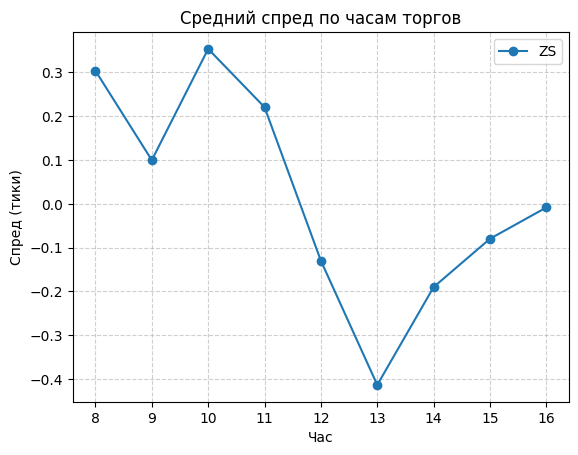

In [72]:
tickers_to_plot = ['ZS']
for ticker in tickers_to_plot:
        spread_by_hour.loc[ticker].plot(marker='o', label=ticker)

plt.legend()
plt.title('Средний спред по часам торгов')
plt.ylabel('Спред (тики)')
plt.xlabel('Час')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [73]:
daily = df_fut_raw.groupby(['comm', 'date_dt']).agg(total_volume=('total', 'sum'),closing_price=('price', 'last'),average_spread=('spread', 'mean')).reset_index()

daily['log_return'] = np.log(daily.groupby('comm')['closing_price'].transform(lambda x: x / x.shift(1)))

daily['abs_return'] = daily['log_return'].abs()

daily['volume_previous_day'] = daily.groupby('comm')['total_volume'].shift(1)
daily['spread_previous_day'] = daily.groupby('comm')['average_spread'].shift(1)

daily = daily.dropna()

corr_volume_vs_return = daily['volume_previous_day'].corr(daily['abs_return'])
corr_spread_vs_return = daily['spread_previous_day'].corr(daily['abs_return'])

print(corr_volume_vs_return)
print(corr_spread_vs_return)

-0.05303956720262561
0.09515300419020345


In [77]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

returns_pivot = fut_main.pivot(index='date_dt', columns='comm', values='log_return')

min_required_days = int(0.7 * len(returns_pivot))
returns_pivot = returns_pivot.dropna(axis=1, thresh=min_required_days)

In [78]:
returns_pivot = returns_pivot.dropna()


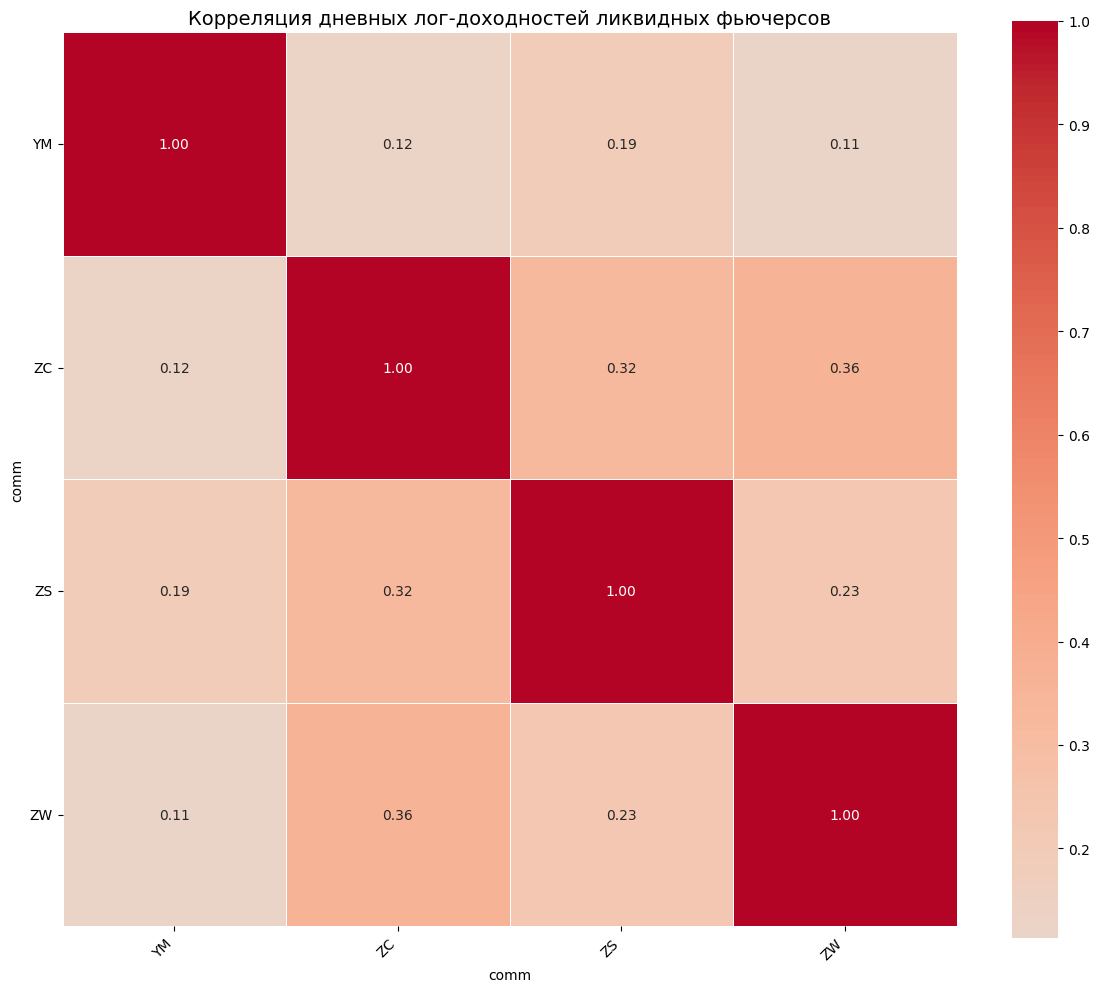

In [79]:
correlation_matrix = returns_pivot.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,square=True, linewidths=0.5)
plt.title('Корреляция дневных лог-доходностей ликвидных фьючерсов', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()